Tissue fit:
log10(y) = -0.5616*(log10(x))^2 + 0.7661*log10(x) + 3.6107

Tumor fit:
log10(y) = -0.4646*(log10(x))^2 + 0.5783*log10(x) + 3.5517

Detector fit:
log10(y) = -0.6353*(log10(x))^2 + 1.1102*log10(x) + 3.8757



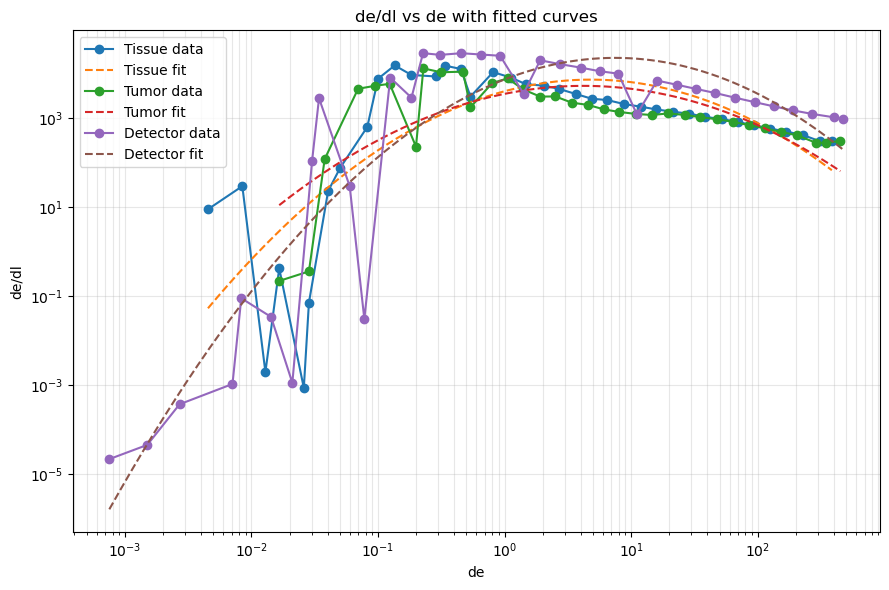

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

file_path = "tumor.root"

vlm_labels = {
    2: "Tissue",
    3: "Tumor",
    6: "Detector"
}

with uproot.open(file_path) as f:
    tree = f["t"]
    de = np.concatenate(tree["de"].array(library="np")).ravel()
    dl = np.concatenate(tree["dl"].array(library="np")).ravel()
    vlm = np.concatenate(tree["vlm"].array(library="np")).ravel()

plt.figure(figsize=(9, 6))

for v in [2, 3, 6]:
    mask = (vlm == v) & (dl > 0) & (de > 0)

    de_v = de[mask]
    dl_v = dl[mask]
    dedl_v = de_v / dl_v

    # skip empty selections
    if len(de_v) == 0:
        continue

    # make log-spaced bins in de
    bins = np.logspace(np.log10(de_v.min()), np.log10(de_v.max()), 40)
    inds = np.digitize(de_v, bins)

    xvals = []
    yvals = []

    for i in range(1, len(bins)):
        bin_mask = (inds == i)
        if np.any(bin_mask):
            xvals.append(np.median(de_v[bin_mask]))
            yvals.append(np.mean(dedl_v[bin_mask]))

    xvals = np.array(xvals)
    yvals = np.array(yvals)

    # keep only positive values for log-log fit
    valid = (xvals > 0) & (yvals > 0)
    xvals = xvals[valid]
    yvals = yvals[valid]

    if len(xvals) < 3:
        continue

    # plot smoothed data
    plt.plot(xvals, yvals, marker="o", linestyle="-", label=f"{vlm_labels[v]} data")

    # ===== best fit in log-log space =====
    # quadratic fit:
    # log10(y) = a*(log10(x))^2 + b*log10(x) + c
    logx = np.log10(xvals)
    logy = np.log10(yvals)

    coeffs = np.polyfit(logx, logy, 2)

    # smooth x for fitted curve
    xfit = np.logspace(np.log10(xvals.min()), np.log10(xvals.max()), 200)
    logxfit = np.log10(xfit)
    logyfit = np.polyval(coeffs, logxfit)
    yfit = 10**logyfit

    a, b, c = coeffs

    plt.plot(
        xfit, yfit, "--",
        label=f"{vlm_labels[v]} fit"
    )

    print(f"{vlm_labels[v]} fit:")
    print(f"log10(y) = {a:.4f}*(log10(x))^2 + {b:.4f}*log10(x) + {c:.4f}")
    print()

plt.xscale("log")
plt.yscale("log")
plt.xlabel("de")
plt.ylabel("de/dl")
plt.title("de/dl vs de with fitted curves")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()